In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import shutil
import random
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

from tensorflow.keras import layers, models
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input

In [ ]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

In [ ]:
import os

# Original dataset path
ORIGINAL_DATASET = "/content/drive/MyDrive/Cabbage_DataSet_unzip/Cabbage DataSet"

# New split dataset path (this will be created)
SPLIT_DATASET = "/content/drive/MyDrive/Cabbage_Project_Split"

print("Original Dataset:", ORIGINAL_DATASET)
print("Split Dataset:", SPLIT_DATASET)

Original Dataset: /content/drive/MyDrive/Cabbage_DataSet_unzip/Cabbage DataSet
Split Dataset: /content/drive/MyDrive/Cabbage_Project_Split


In [ ]:
import os

classes = sorted(os.listdir(ORIGINAL_DATASET))

print("Dataset Summary\n")

for cls in classes:

    cls_path = os.path.join(ORIGINAL_DATASET, cls)

    # Handle nested folder (Healthy Leaves)
    items = os.listdir(cls_path)

    if len(items) == 1 and os.path.isdir(os.path.join(cls_path, items[0])):
        cls_path = os.path.join(cls_path, items[0])

    images = [
        img for img in os.listdir(cls_path)
        if img.lower().endswith((".jpg", ".jpeg", ".png"))
    ]

    print(f"{cls}: {len(images)} images")

Dataset Summary

Alternaria_Leaf_Spot: 200 images
Black Rot: 200 images
Club Root: 200 images
Downy Mildew: 200 images
Healthy Leaves: 147 images


In [ ]:
import shutil

# Remove old split if it exists
if os.path.exists(SPLIT_DATASET):
    shutil.rmtree(SPLIT_DATASET)

os.makedirs(SPLIT_DATASET)

print("Fresh split directory created successfully!")

Fresh split directory created successfully!


In [ ]:
from sklearn.model_selection import train_test_split

for cls in classes:

    src = os.path.join(ORIGINAL_DATASET, cls)

    # Handle nested folder automatically
    items = os.listdir(src)

    if len(items) == 1 and os.path.isdir(os.path.join(src, items[0])):
        src = os.path.join(src, items[0])

    images = [
        img for img in os.listdir(src)
        if img.lower().endswith((".jpg", ".jpeg", ".png"))
    ]
    # First split → Train+Validation and Test
    train_val, test = train_test_split(
        images,
        test_size=0.20,
        random_state=42,
        shuffle=True
    )

    # Second split → Train and Validation
    train, val = train_test_split(
        train_val,
        test_size=0.125,
        random_state=42,
        shuffle=True
    )

    # Create folders
    for split in ["train", "val", "test"]:
        os.makedirs(
            os.path.join(SPLIT_DATASET, split, cls),
            exist_ok=True
        )

    # Copy images
    for img in train:
        shutil.copy(
            os.path.join(src, img),
            os.path.join(SPLIT_DATASET, "train", cls, img)
        )

    for img in val:
        shutil.copy(
            os.path.join(src, img),
            os.path.join(SPLIT_DATASET, "val", cls, img)
        )

    for img in test:
        shutil.copy(
            os.path.join(src, img),
            os.path.join(SPLIT_DATASET, "test", cls, img)
        )

print("✅ Dataset split completed successfully!")

✅ Dataset split completed successfully!


In [ ]:
for split in ["train", "val", "test"]:

    print(f"\n========== {split.upper()} ==========")

    split_path = os.path.join(SPLIT_DATASET, split)

    for cls in sorted(os.listdir(split_path)):
        count = len(os.listdir(os.path.join(split_path, cls)))
        print(f"{cls}: {count}")


========== TRAIN ==========
Alternaria_Leaf_Spot: 140
Black Rot: 140
Club Root: 140
Downy Mildew: 140
Healthy Leaves: 102

========== VAL ==========
Alternaria_Leaf_Spot: 20
Black Rot: 20
Club Root: 20
Downy Mildew: 20
Healthy Leaves: 15

========== TEST ==========
Alternaria_Leaf_Spot: 40
Black Rot: 40
Club Root: 40
Downy Mildew: 40
Healthy Leaves: 30


In [ ]:
import tensorflow as tf

IMG_HEIGHT = 224
IMG_WIDTH = 224

BATCH_SIZE = 16

AUTOTUNE = tf.data.AUTOTUNE

In [ ]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(SPLIT_DATASET, "train"),
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=42,
    label_mode="int"
)

Found 662 files belonging to 5 classes.


In [ ]:
val_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(SPLIT_DATASET, "val"),
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    shuffle=False,
    label_mode="int"
)

Found 95 files belonging to 5 classes.


In [ ]:
test_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(SPLIT_DATASET, "test"),
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    shuffle=False,
    label_mode="int"
)

Found 190 files belonging to 5 classes.


In [ ]:
class_names = train_ds.class_names

print(class_names)

['Alternaria_Leaf_Spot', 'Black Rot', 'Club Root', 'Downy Mildew', 'Healthy Leaves']


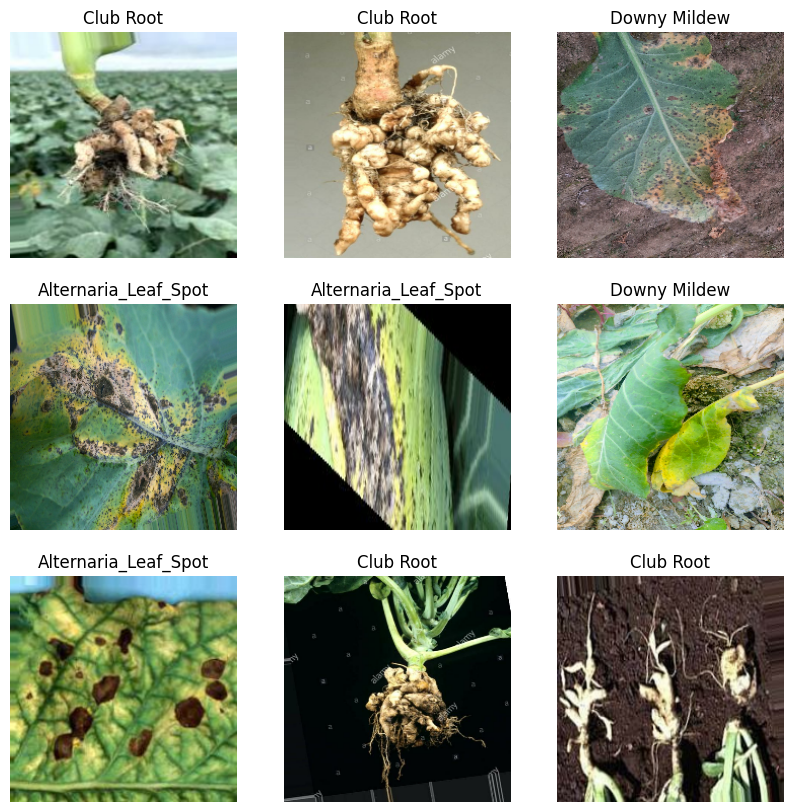

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,10))

for images, labels in train_ds.take(1):

    for i in range(9):

        ax = plt.subplot(3,3,i+1)

        plt.imshow(images[i].numpy().astype("uint8"))

        plt.title(class_names[labels[i]])

        plt.axis("off")

plt.show()

In [ ]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.15),
    tf.keras.layers.RandomZoom(0.15),
    tf.keras.layers.RandomContrast(0.10)
])

In [ ]:
from tensorflow.keras.applications.resnet50 import preprocess_input

In [ ]:
train_ds = train_ds.map(
    lambda x, y: (preprocess_input(data_augmentation(x)), y),
    num_parallel_calls=AUTOTUNE
)

val_ds = val_ds.map(
    lambda x, y: (preprocess_input(x), y),
    num_parallel_calls=AUTOTUNE
)

test_ds = test_ds.map(
    lambda x, y: (preprocess_input(x), y),
    num_parallel_calls=AUTOTUNE
)

train_ds = train_ds.prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)
test_ds = test_ds.prefetch(AUTOTUNE)

In [ ]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# Collect labels from the training dataset
train_labels = []

for images, labels in train_ds.unbatch():
    train_labels.append(labels.numpy())

train_labels = np.array(train_labels)

# Compute class weights
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_labels),
    y=train_labels
)

class_weights = dict(enumerate(class_weights))

print(class_weights)

{0: np.float64(0.9457142857142857), 1: np.float64(0.9457142857142857), 2: np.float64(0.9457142857142857), 3: np.float64(0.9457142857142857), 4: np.float64(1.2980392156862746)}


In [ ]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras import layers, models

# Load pretrained ResNet50
base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

# Freeze the base model
base_model.trainable = False

# Build classifier
model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),

    layers.Dense(
        256,
        activation='relu'
    ),

    layers.Dropout(0.5),

    layers.Dense(
        len(class_names),
        activation='softmax'
    )
])

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-3
    ),

    loss='sparse_categorical_crossentropy',

    metrics=['accuracy']
)

In [ ]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │         1,285 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,113,541 (91.99 MB)

 Trainable params: 525,829 (2.01 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [ ]:
callbacks = [

    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=4,
        restore_best_weights=True
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.2,
        patience=2,
        min_lr=1e-6
    ),

    tf.keras.callbacks.ModelCheckpoint(
        "best_resnet50.keras",
        monitor="val_accuracy",
        save_best_only=True
    )
]

In [ ]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=callbacks,
    class_weight=class_weights
)

Epoch 1/10
42/42 ━━━━━━━━━━━━━━━━━━━━ 209s 5s/step - accuracy: 0.7976 - loss: 0.5993 - val_accuracy: 0.9684 - val_loss: 0.0892 - learning_rate: 0.0010
Epoch 2/10
42/42 ━━━━━━━━━━━━━━━━━━━━ 175s 4s/step - accuracy: 0.9199 - loss: 0.1971 - val_accuracy: 0.9684 - val_loss: 0.0897 - learning_rate: 0.0010
Epoch 3/10
42/42 ━━━━━━━━━━━━━━━━━━━━ 206s 4s/step - accuracy: 0.9486 - loss: 0.1212 - val_accuracy: 0.9789 - val_loss: 0.0771 - learning_rate: 0.0010
Epoch 4/10
42/42 ━━━━━━━━━━━━━━━━━━━━ 195s 5s/step - accuracy: 0.9607 - loss: 0.0881 - val_accuracy: 0.9895 - val_loss: 0.0385 - learning_rate: 0.0010
Epoch 5/10
42/42 ━━━━━━━━━━━━━━━━━━━━ 181s 4s/step - accuracy: 0.9728 - loss: 0.0690 - val_accuracy: 0.9789 - val_loss: 0.0419 - learning_rate: 0.0010
Epoch 6/10
42/42 ━━━━━━━━━━━━━━━━━━━━ 194s 5s/step - accuracy: 0.9698 - loss: 0.0895 - val_accuracy: 0.9789 - val_loss: 0.0647 - learning_rate: 0.0010
Epoch 7/10
42/42 ━━━━━━━━━━━━━━━━━━━━ 178s 4s/step - accuracy: 0.9789 - loss: 0.0650 - val_acc

In [ ]:
test_loss, test_accuracy = model.evaluate(test_ds)

print(f"Test Accuracy : {test_accuracy:.4f}")
print(f"Test Loss     : {test_loss:.4f}")

12/12 ━━━━━━━━━━━━━━━━━━━━ 44s 3s/step - accuracy: 0.9895 - loss: 0.0319
Test Accuracy : 0.9895
Test Loss     : 0.0319


In [ ]:
import numpy as np

y_true = []
y_pred = []

for images, labels in test_ds:
    predictions = model.predict(images, verbose=0)

    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(predictions, axis=1))

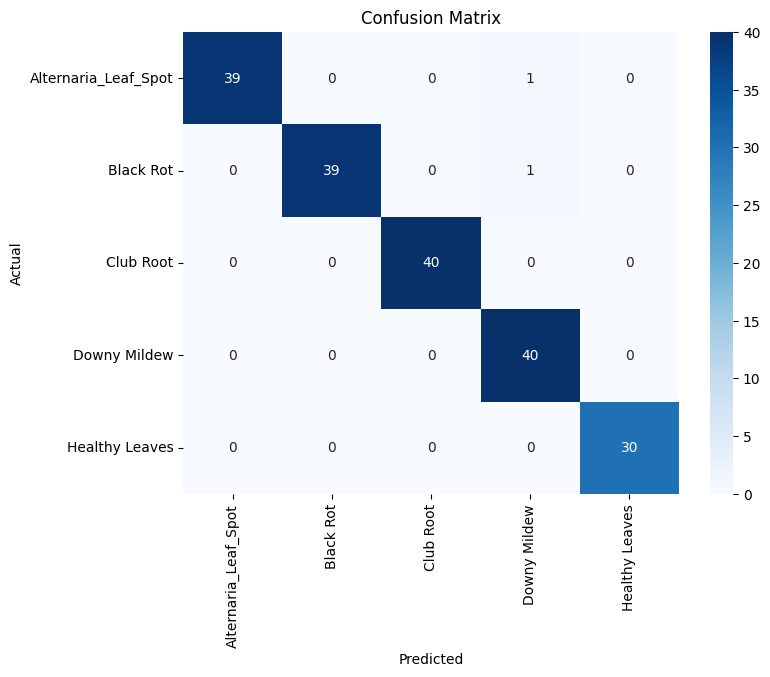

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names
    )
)

                      precision    recall  f1-score   support

Alternaria_Leaf_Spot       1.00      0.97      0.99        40
           Black Rot       1.00      0.97      0.99        40
           Club Root       1.00      1.00      1.00        40
        Downy Mildew       0.95      1.00      0.98        40
      Healthy Leaves       1.00      1.00      1.00        30

            accuracy                           0.99       190
           macro avg       0.99      0.99      0.99       190
        weighted avg       0.99      0.99      0.99       190



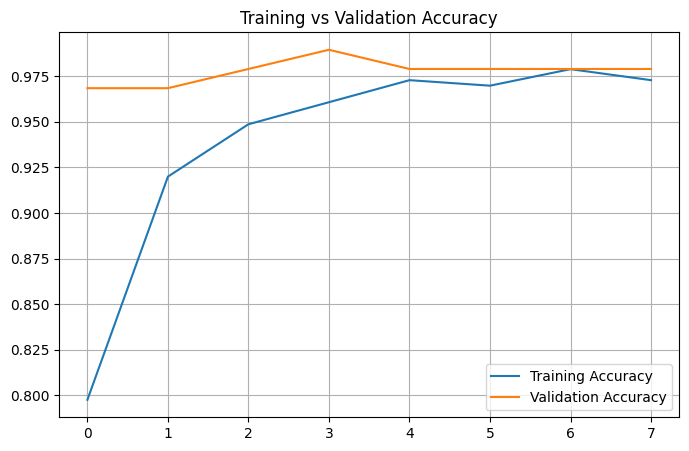

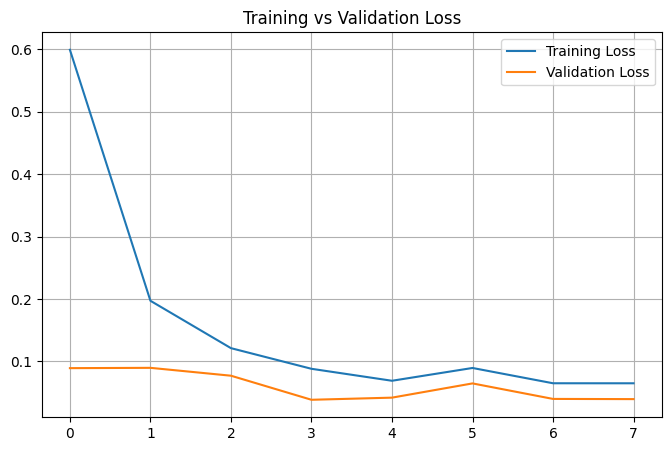

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.legend()
plt.grid(True)
plt.title("Training vs Validation Accuracy")

plt.show()


plt.figure(figsize=(8,5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.legend()
plt.grid(True)
plt.title("Training vs Validation Loss")

plt.show()

In [ ]:
model.save("/content/drive/MyDrive/Cabbage_ResNet50_Final.keras")

print("Model Saved Successfully!")

Model Saved Successfully!


In [ ]:
loaded_model = tf.keras.models.load_model(
    "/content/drive/MyDrive/Cabbage_ResNet50_Final.keras"
)

print("Model Loaded Successfully!")

Model Loaded Successfully!


In [ ]:
from tensorflow.keras.preprocessing import image
import numpy as np

img_path = "/content/drive/MyDrive/Cabbage_Project_Split/test/Alternaria_Leaf_Spot/aug_15.jpg"   # Replace with your image path

img = image.load_img(img_path, target_size=(224,224))

img_array = image.img_to_array(img)

img_array = np.expand_dims(img_array, axis=0)

img_array = preprocess_input(img_array)

prediction = loaded_model.predict(img_array)

predicted_class = class_names[np.argmax(prediction)]

confidence = np.max(prediction) * 100

print("Prediction :", predicted_class)
print(f"Confidence : {confidence:.2f}%")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 739ms/step
Prediction : Alternaria_Leaf_Spot
Confidence : 99.96%
